# Natural Language Processing Toolkit

In [1]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [2]:
text = ["Lincoln freed many slaves, Lincoln was President of USA",
        "USA is fourth largest country in the world",
        "USA has coastline on east and west"]

# Tokenisation

In [3]:
tokenized_text = []
for send in text:
    tokenized_text += nltk.word_tokenize(send)

In [4]:
tokenized_text

['Lincoln',
 'freed',
 'many',
 'slaves',
 ',',
 'Lincoln',
 'was',
 'President',
 'of',
 'USA',
 'USA',
 'is',
 'fourth',
 'largest',
 'country',
 'in',
 'the',
 'world',
 'USA',
 'has',
 'coastline',
 'on',
 'east',
 'and',
 'west']

In [5]:
import string
def clean_text(tokens):
    tokens = [w.lower() for w in tokens]
    return tokens

In [6]:
cleaned_text = clean_text(tokenized_text)
cleaned_text

['lincoln',
 'freed',
 'many',
 'slaves',
 ',',
 'lincoln',
 'was',
 'president',
 'of',
 'usa',
 'usa',
 'is',
 'fourth',
 'largest',
 'country',
 'in',
 'the',
 'world',
 'usa',
 'has',
 'coastline',
 'on',
 'east',
 'and',
 'west']

In [7]:
unique_words_count = len(set(cleaned_text))
unique_words_count

22

# Count Vectoriser

In [8]:
vocab = {}
for token in cleaned_text:
    if token not in vocab:
        vocab[token] = 1
    else:
        vocab[token] += 1

In [9]:
vocab

{'lincoln': 2,
 'freed': 1,
 'many': 1,
 'slaves': 1,
 ',': 1,
 'was': 1,
 'president': 1,
 'of': 1,
 'usa': 3,
 'is': 1,
 'fourth': 1,
 'largest': 1,
 'country': 1,
 'in': 1,
 'the': 1,
 'world': 1,
 'has': 1,
 'coastline': 1,
 'on': 1,
 'east': 1,
 'and': 1,
 'west': 1}

## Creating Vectors

In [10]:
rows = []
for doc in text:
    vector = [0] * len(vocab)
    for word in clean_text(nltk.word_tokenize(doc)):
        if word in vocab:
            vector[list(vocab.keys()).index(word)] += 1
    rows.append(vector)

In [12]:
rows

[[2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]]

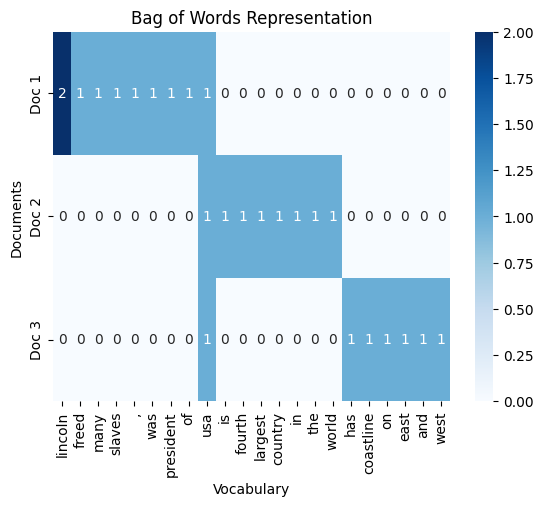

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.Figure(figsize=(10, 8))
sns.heatmap(rows, annot=True, cmap="Blues", xticklabels=vocab.keys(), yticklabels=[f"Doc {i+1}" for i in range(len(text))])
plt.title("Bag of Words Representation")
plt.ylabel("Documents")
plt.xlabel("Vocabulary")
plt.show()

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

vectors = vectorizer.fit_transform(text)
vectors.toarray()

array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0],
       [0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1],
       [1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0]])

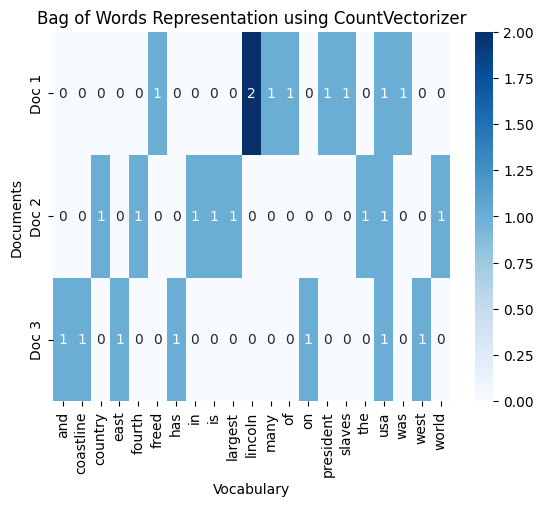

In [24]:
plt.Figure(figsize=(10, 8))
sns.heatmap(vectors.toarray(), annot=True, cmap="Blues", xticklabels=vectorizer.get_feature_names_out(), yticklabels=[f"Doc {i+1}" for i in range(len(text))])
plt.title("Bag of Words Representation using CountVectorizer")
plt.ylabel("Documents")
plt.xlabel("Vocabulary")
plt.show()